# Projeto — Classificação de lesões de pele com ResNet50


In [44]:
!pip -q install kagglehub

In [45]:
import os
import random
import math
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
caminho_download = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset baixado em:", caminho_download)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset baixado em: /kaggle/input/skin-cancer-mnist-ham10000


In [4]:
raiz = Path(caminho_download)

arquivos_csv = list(raiz.rglob("HAM10000_metadata.csv"))
if not arquivos_csv:
    raise FileNotFoundError("Arquivo HAM10000_metadata.csv não encontrado.")

caminho_metadata = arquivos_csv[0]
df = pd.read_csv(caminho_metadata)

mapa_imagens = {
    caminho.stem: str(caminho)
    for caminho in raiz.rglob("*.jpg")
}

df["caminho_imagem"] = df["image_id"].map(mapa_imagens)
df = df.dropna(subset=["caminho_imagem"]).copy()

nomes_classes = {
    "akiec": "queratose_actinica_carcinoma_intraepitelial",
    "bcc": "carcinoma_basocelular",
    "bkl": "lesao_benigna_queratose",
    "df": "dermatofibroma",
    "mel": "melanoma",
    "nv": "nevo_melanocitico",
    "vasc": "lesao_vascular"
}

df["classe_descritiva"] = df["dx"].map(nomes_classes)

display(df.head())
print("Total de imagens com caminho encontrado:", len(df))
print("Classes:", sorted(df["dx"].unique()))

,lesion_id,image_id,dx,dx_type,age,sex,localization,caminho_imagem,classe_descritiva
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,lesao_benigna_queratose
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,lesao_benigna_queratose
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,lesao_benigna_queratose
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,lesao_benigna_queratose
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,lesao_benigna_queratose


Total de imagens com caminho encontrado: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


/tmp/ipykernel_2800/3833977021.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


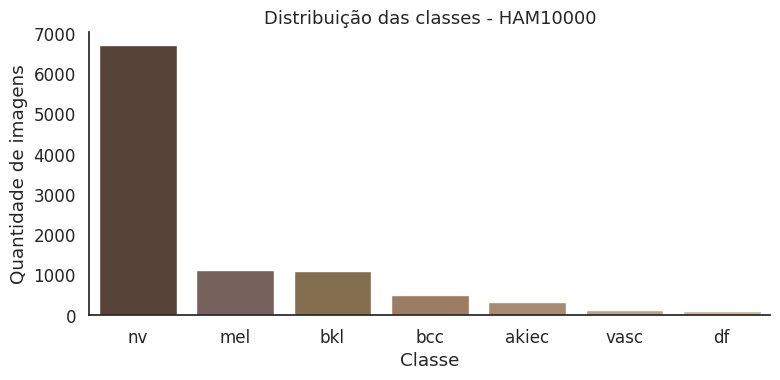

In [31]:
contagem = df["dx"].value_counts().sort_values(ascending=False)


paleta_marrom = [
    "#5C4033",
    "#7B5E57",
    "#8B6F47",
    "#A67B5B",
    "#B08968",
    "#C4A484",
    "#D2B48C"
]

sns.set_style("white")

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    x=contagem.index,
    y=contagem.values,
    palette=paleta_marrom
)

ax.set_title("Distribuição das classes - HAM10000", fontsize=13)
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de imagens")

sns.despine()

ax.set_facecolor("none")
plt.gcf().patch.set_alpha(0)

plt.tight_layout()

plt.savefig("grafico_ham10000_marrom_transparente.png", dpi=300, transparent=True)
plt.show()

##Preparação dos dados

In [6]:
treino_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["dx"],
    random_state=SEED
)

validacao_df, teste_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=SEED
)

print("Treino:", treino_df.shape)
print("Validação:", validacao_df.shape)
print("Teste:", teste_df.shape)

print("\nDistribuição no treino:")
display(treino_df["dx"].value_counts(normalize=True).round(3))

Treino: (7010, 9)
Validação: (1502, 9)
Teste: (1503, 9)

Distribuição no treino:


,proportion
dx,
nv,0.669
mel,0.111
bkl,0.110
bcc,0.051
akiec,0.033
vasc,0.014
df,0.012


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

gerador_treino = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest"
)

gerador_validacao_teste = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

treino_gen = gerador_treino.flow_from_dataframe(
    dataframe=treino_df,
    x_col="caminho_imagem",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validacao_gen = gerador_validacao_teste.flow_from_dataframe(
    dataframe=validacao_df,
    x_col="caminho_imagem",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

teste_gen = gerador_validacao_teste.flow_from_dataframe(
    dataframe=teste_df,
    x_col="caminho_imagem",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

classes_modelo = list(treino_gen.class_indices.keys())
num_classes = len(classes_modelo)

print("Classes usadas pelo modelo:", classes_modelo)
print("Número de classes:", num_classes)


Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Classes usadas pelo modelo: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Número de classes: 7


In [8]:
# Ajuste dos pesos
pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(treino_gen.classes),
    y=treino_gen.classes
)

class_weight = dict(zip(np.unique(treino_gen.classes), pesos))
class_weight


{np.int64(0): np.float64(4.37305053025577),
 np.int64(1): np.float64(2.7817460317460316),
 np.int64(2): np.float64(1.3022478172023035),
 np.int64(3): np.float64(12.36331569664903),
 np.int64(4): np.float64(1.285530900421786),
 np.int64(5): np.float64(0.21338772031292808),
 np.int64(6): np.float64(10.115440115440116)}

In [9]:
base_resnet = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_resnet.trainable = False

entradas = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = base_resnet(entradas, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.50)(x)
saidas = layers.Dense(num_classes, activation="softmax")(x)

modelo = models.Model(inputs=entradas, outputs=saidas)

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 530,439 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Treinamento — fase 1


In [10]:
EPOCHS_FASE_1 = 8

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

historico_fase_1 = modelo.fit(
    treino_gen,
    validation_data=validacao_gen,
    epochs=EPOCHS_FASE_1,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 260s 558ms/step - accuracy: 0.3131 - loss: 2.0468 - val_accuracy: 0.5613 - val_loss: 1.2598 - learning_rate: 1.0000e-04
Epoch 2/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 166s 379ms/step - accuracy: 0.4484 - loss: 1.5093 - val_accuracy: 0.5919 - val_loss: 1.1454 - learning_rate: 1.0000e-04
Epoch 3/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 165s 377ms/step - accuracy: 0.5054 - loss: 1.3427 - val_accuracy: 0.6471 - val_loss: 1.0441 - learning_rate: 1.0000e-04
Epoch 4/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 165s 376ms/step - accuracy: 0.5221 - loss: 1.2483 - val_accuracy: 0.6205 - val_loss: 1.1082 - learning_rate: 1.0000e-04
Epoch 5/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 203s 379ms/step - accuracy: 0.5553 - loss: 1.1508 - val_accuracy: 0.6125 - val_loss: 1.0403 - learning_rate: 1.0000e-04
Epoch 6/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 164s 373ms/step - accuracy: 0.5641 - loss: 1.1057 - val_accuracy: 0.6318 - val_loss: 1.0050 - learning_rate: 1.0000e-04
Epoch 7/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 166s 37

## Fine-tuning — fase 2


In [11]:
base_resnet.trainable = True

# Congela todas camadas menos as últimas 30
for camada in base_resnet.layers[:-30]:
    camada.trainable = False

# Mantém camadas de BatchNormalization congeladas, evitando instabilidade.
for camada in base_resnet.layers:
    if isinstance(camada, tf.keras.layers.BatchNormalization):
        camada.trainable = False

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,247 (92.02 MB)

 Trainable params: 14,959,111 (57.06 MB)

 Non-trainable params: 9,163,136 (34.95 MB)

In [12]:
EPOCHS_FASE_2 = 8

historico_fase_2 = modelo.fit(
    treino_gen,
    validation_data=validacao_gen,
    epochs=EPOCHS_FASE_2,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 204s 422ms/step - accuracy: 0.6053 - loss: 1.0057 - val_accuracy: 0.6997 - val_loss: 0.8102 - learning_rate: 1.0000e-05
Epoch 2/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 171s 390ms/step - accuracy: 0.6191 - loss: 0.9115 - val_accuracy: 0.6471 - val_loss: 0.9828 - learning_rate: 1.0000e-05
Epoch 3/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 395ms/step - accuracy: 0.6243 - loss: 0.8110 - val_accuracy: 0.6618 - val_loss: 0.9395 - learning_rate: 1.0000e-05
Epoch 4/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 169s 384ms/step - accuracy: 0.6535 - loss: 0.7372 - val_accuracy: 0.6724 - val_loss: 0.9180 - learning_rate: 3.0000e-06


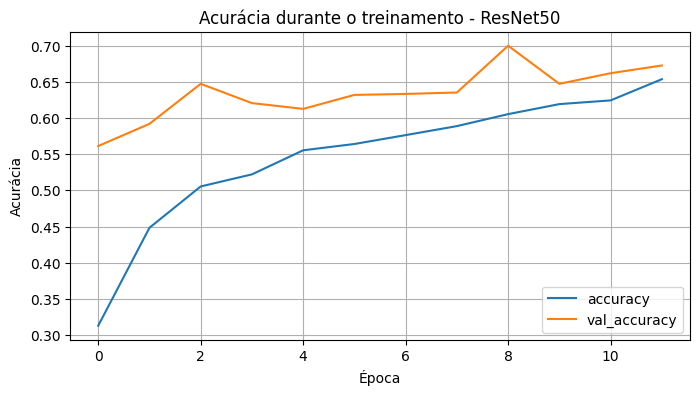

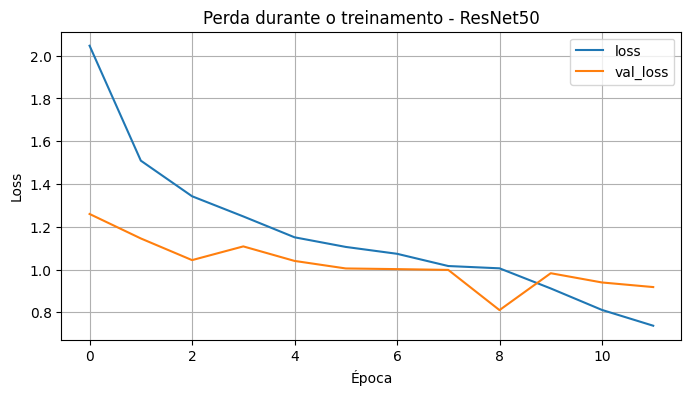

In [13]:
# Junta o histórico das duas fases para visualizar a evolução completa.

historico_total = {}
for chave in historico_fase_1.history.keys():
    historico_total[chave] = historico_fase_1.history[chave] + historico_fase_2.history.get(chave, [])

historico_df = pd.DataFrame(historico_total)

historico_df[["accuracy", "val_accuracy"]].plot(figsize=(8, 4))
plt.title("Acurácia durante o treinamento - ResNet50")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

historico_df[["loss", "val_loss"]].plot(figsize=(8, 4))
plt.title("Perda durante o treinamento - ResNet50")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [14]:
resultado_teste = modelo.evaluate(teste_gen, verbose=0)
print(f"Loss no teste: {resultado_teste[0]:.4f}")
print(f"Acurácia no teste: {resultado_teste[1]:.4f}")


Loss no teste: 0.8856
Acurácia no teste: 0.6660


In [15]:
teste_gen.reset()

probabilidades = modelo.predict(teste_gen, verbose=1)
y_predito = np.argmax(probabilidades, axis=1)
y_real = teste_gen.classes

idx_para_classe = {v: k for k, v in teste_gen.class_indices.items()}
nomes_ordenados = [idx_para_classe[i] for i in range(len(idx_para_classe))]

print(classification_report(
    y_real,
    y_predito,
    target_names=nomes_ordenados,
    zero_division=0
))


94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step
              precision    recall  f1-score   support

       akiec       0.44      0.33      0.38        49
         bcc       0.43      0.53      0.47        77
         bkl       0.41      0.67      0.51       165
          df       0.10      0.47      0.17        17
         mel       0.39      0.57      0.46       167
          nv       0.96      0.71      0.81      1006
        vasc       0.52      0.73      0.60        22

    accuracy                           0.67      1503
   macro avg       0.46      0.57      0.49      1503
weighted avg       0.77      0.67      0.70      1503



94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step


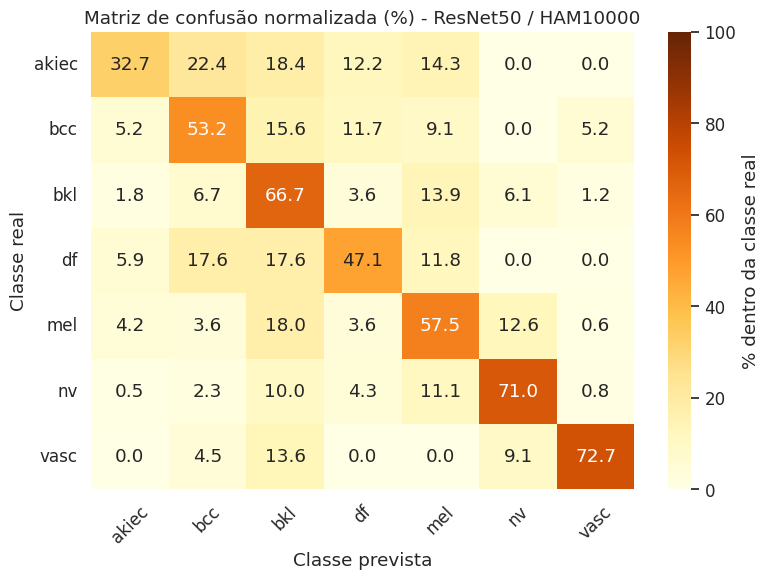

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

teste_gen.reset()
y_prob = modelo.predict(teste_gen)

y_pred = np.argmax(y_prob, axis=1)

y_true = teste_gen.classes

classes = list(teste_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

cm_percentual = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_percentual,
    annot=True,
    fmt=".1f",
    cmap="YlOrBr",
    xticklabels=classes,
    yticklabels=classes,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% dentro da classe real"}
)

plt.title("Matriz de confusão normalizada (%) - ResNet50 / HAM10000")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

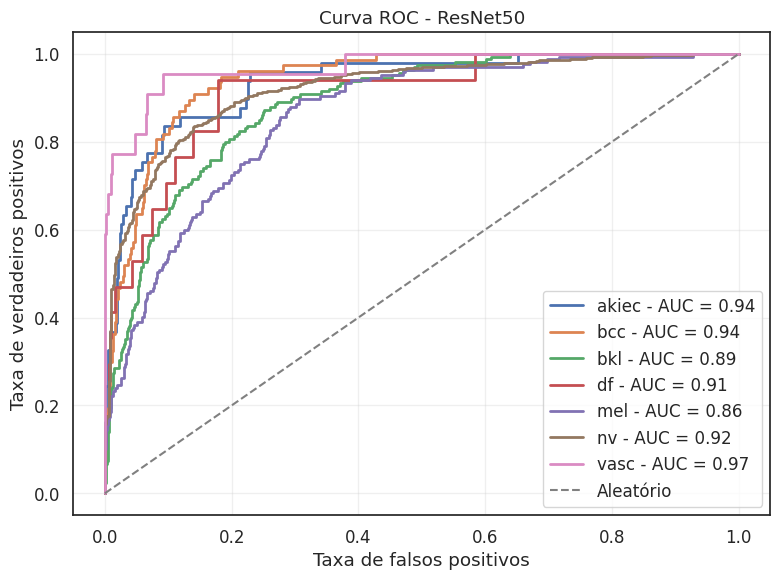

In [37]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8, 6))

# Curva ROC para cada classe
for i, classe in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{classe} - AUC = {roc_auc:.2f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Aleatório"
)

plt.title("Curva ROC - ResNet50")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Demonstração do modelo

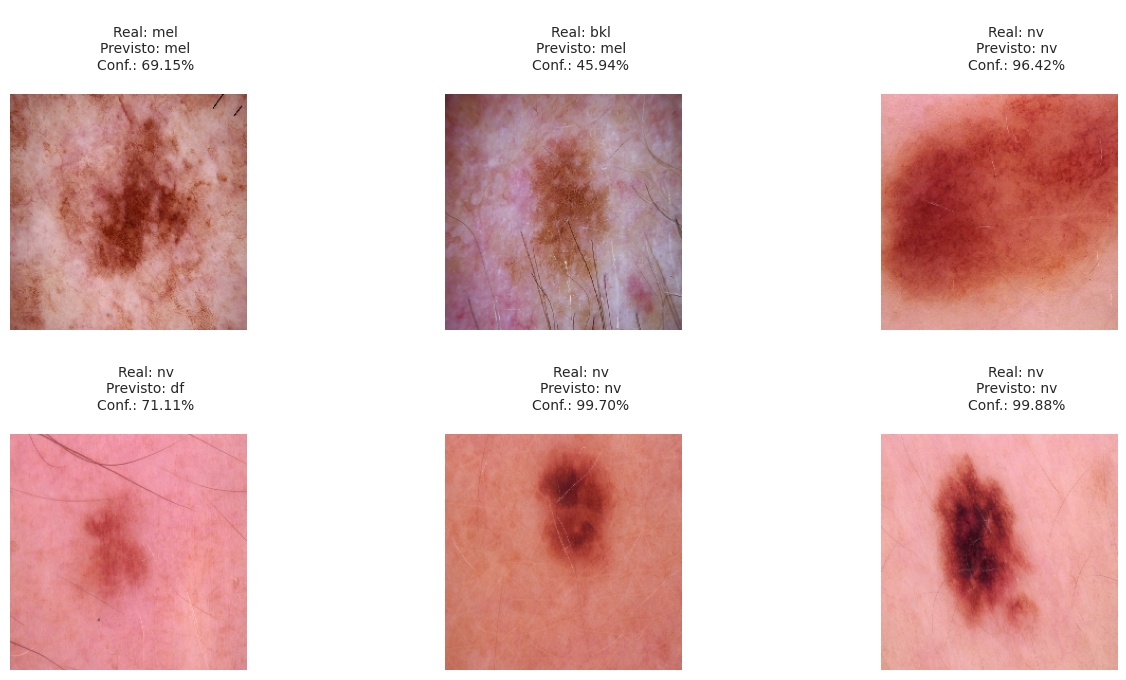

In [43]:
def demonstrar_previsoes_pele(teste_df, modelo, qtd=6):
    amostra = teste_df.sample(qtd, random_state=666).reset_index(drop=True)

    plt.figure(figsize=(14, 7))

    for i, linha in amostra.iterrows():
        caminho = linha["caminho_imagem"]
        classe_real = linha["dx"]

        img = tf.keras.utils.load_img(caminho, target_size=IMG_SIZE)
        array = tf.keras.utils.img_to_array(img)
        array = preprocess_input(array)
        array = np.expand_dims(array, axis=0)

        prob = modelo.predict(array, verbose=0)[0]
        indice = np.argmax(prob)
        classe_prevista = idx_para_classe[indice]
        confianca = prob[indice]

        plt.subplot(2, math.ceil(qtd / 2), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
        f"""
        Real: {classe_real}
        Previsto: {classe_prevista}
        Conf.: {confianca:.2%}
        """,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

demonstrar_previsoes_pele(teste_df, modelo, qtd=6)


In [20]:
def prever_lesao(caminho_imagem):
    img = tf.keras.utils.load_img(caminho_imagem, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(img)
    array = preprocess_input(array)
    array = np.expand_dims(array, axis=0)

    probabilidades = modelo.predict(array, verbose=0)[0]
    indice = np.argmax(probabilidades)

    classe_curta = idx_para_classe[indice]
    classe_texto = nomes_classes.get(classe_curta, classe_curta)

    print("Classe prevista:", classe_curta)
    print("Descrição:", classe_texto)
    print("Confiança:", f"{probabilidades[indice]:.2%}")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{classe_curta} — {probabilidades[indice]:.2%}")
    plt.show()


Classe prevista: df
Descrição: dermatofibroma
Confiança: 66.01%


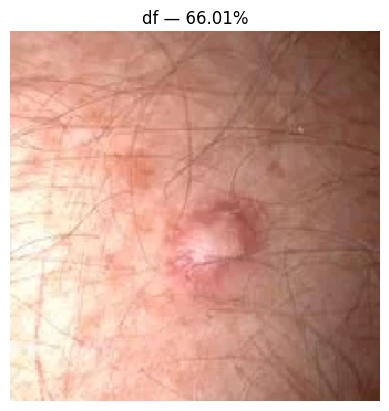

In [22]:
prever_lesao("/content/dermatofibroma.png")